In [1]:
import os
import copy
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [3]:
input_file = "quantum_encoded_healthcare_data.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"{input_file} was not found. "
        "Run Quantum Data Encoding first."
    )

X_train_df = pd.read_excel(
    input_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    input_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    input_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    input_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    input_file,
    sheet_name="Class_Mapping"
)

print("Training features:", X_train_df.shape)
print("Testing features:", X_test_df.shape)
print("Training targets:", y_train_df.shape)
print("Testing targets:", y_test_df.shape)

Training features: (400, 4)
Testing features: (100, 4)
Training targets: (400, 2)
Testing targets: (100, 2)


In [4]:
target_column = "encoded_target"

if target_column not in y_train_df.columns:
    raise KeyError(
        f"{target_column} is missing. "
        f"Available columns: {y_train_df.columns.tolist()}"
    )

X_full_train = X_train_df.to_numpy(
    dtype=np.float32
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

y_full_train = y_train_df[
    target_column
].to_numpy(dtype=np.int64)

y_test = y_test_df[
    target_column
].to_numpy(dtype=np.int64)

n_qubits = X_full_train.shape[1]
class_ids = np.sort(np.unique(y_full_train))
n_classes = len(class_ids)

assert n_qubits == 4
assert n_classes == 12
assert np.array_equal(
    class_ids,
    np.arange(n_classes)
)

print("Qubits:", n_qubits)
print("Classes:", n_classes)

Qubits: 4
Classes: 12


In [5]:
X_train, X_validation, y_train, y_validation = (
    train_test_split(
        X_full_train,
        y_full_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_full_train
    )
)

print("Optimization training:", X_train.shape)
print("Optimization validation:", X_validation.shape)
print("Untouched test set:", X_test.shape)

Optimization training: (320, 4)
Optimization validation: (80, 4)
Untouched test set: (100, 4)


In [6]:
def create_data_loader(
    features,
    targets,
    batch_size=16,
    shuffle=False
):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    target_tensor = torch.tensor(
        targets,
        dtype=torch.long
    )

    return DataLoader(
        TensorDataset(
            feature_tensor,
            target_tensor
        ),
        batch_size=batch_size,
        shuffle=shuffle
    )


train_loader = create_data_loader(
    X_train,
    y_train,
    batch_size=16,
    shuffle=True
)

validation_loader = create_data_loader(
    X_validation,
    y_validation,
    batch_size=16
)

test_loader = create_data_loader(
    X_test,
    y_test,
    batch_size=16
)

In [7]:
circuit_candidates = [
    {
        "circuit_name": "Basic_1_Layer",
        "template": "basic",
        "layers": 1
    },
    {
        "circuit_name": "Basic_2_Layers",
        "template": "basic",
        "layers": 2
    },
    {
        "circuit_name": "Strong_1_Layer",
        "template": "strong",
        "layers": 1
    },
    {
        "circuit_name": "Strong_2_Layers",
        "template": "strong",
        "layers": 2
    }
]

pd.DataFrame(circuit_candidates)

,circuit_name,template,layers
0,Basic_1_Layer,basic,1
1,Basic_2_Layers,basic,2
2,Strong_1_Layer,strong,1
3,Strong_2_Layers,strong,2


In [8]:
def build_quantum_circuit(
    template_name,
    number_of_layers
):
    device = qml.device(
        "default.qubit",
        wires=n_qubits
    )

    wires = list(range(n_qubits))

    if template_name == "basic":
        weight_shapes = {
            "weights": (
                number_of_layers,
                n_qubits
            )
        }

    elif template_name == "strong":
        weight_shapes = {
            "weights": (
                number_of_layers,
                n_qubits,
                3
            )
        }

    else:
        raise ValueError(
            f"Unknown template: {template_name}"
        )

    @qml.qnode(
        device,
        interface="torch",
        diff_method="backprop"
    )
    def circuit(inputs, weights):
        qml.AngleEmbedding(
            features=inputs,
            wires=wires,
            rotation="Y"
        )

        if template_name == "basic":
            qml.BasicEntanglerLayers(
                weights=weights,
                wires=wires,
                rotation=qml.RY
            )

        else:
            qml.StronglyEntanglingLayers(
                weights=weights,
                wires=wires
            )

        return [
            qml.expval(qml.PauliZ(wire))
            for wire in wires
        ]

    return circuit, weight_shapes

In [9]:
class OptimizedQuantumClassifier(nn.Module):
    def __init__(
        self,
        quantum_circuit,
        weight_shapes,
        number_of_classes
    ):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            number_of_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(
            inputs
        )

        return self.output_layer(
            quantum_features
        )

In [10]:
def evaluate_model(
    model,
    data_loader,
    loss_function
):
    model.eval()

    total_loss = 0.0
    targets_all = []
    predictions_all = []

    with torch.no_grad():
        for features, targets in data_loader:
            logits = model(features)
            loss = loss_function(logits, targets)

            total_loss += (
                loss.item() * features.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            targets_all.extend(
                targets.cpu().numpy()
            )

            predictions_all.extend(
                predictions.cpu().numpy()
            )

    average_loss = (
        total_loss / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        targets_all,
        predictions_all
    )

    _, _, macro_f1, _ = (
        precision_recall_fscore_support(
            targets_all,
            predictions_all,
            average="macro",
            zero_division=0
        )
    )

    return average_loss, accuracy, macro_f1

In [11]:
def optimize_candidate(
    candidate,
    maximum_epochs=15,
    patience=4
):
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    circuit, weight_shapes = (
        build_quantum_circuit(
            candidate["template"],
            candidate["layers"]
        )
    )

    model = OptimizedQuantumClassifier(
        quantum_circuit=circuit,
        weight_shapes=weight_shapes,
        number_of_classes=n_classes
    )

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=1e-4
    )

    best_validation_loss = float("inf")
    best_validation_f1 = -1
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    start_time = time.time()

    for epoch in range(1, maximum_epochs + 1):
        model.train()

        total_train_loss = 0.0
        training_targets = []
        training_predictions = []

        for features, targets in train_loader:
            optimizer.zero_grad()

            logits = model(features)
            loss = loss_function(logits, targets)

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * features.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            training_targets.extend(
                targets.cpu().numpy()
            )

            training_predictions.extend(
                predictions.cpu().numpy()
            )

        train_loss = (
            total_train_loss
            / len(train_loader.dataset)
        )

        train_accuracy = accuracy_score(
            training_targets,
            training_predictions
        )

        validation_loss, validation_accuracy, validation_f1 = (
            evaluate_model(
                model,
                validation_loader,
                loss_function
            )
        )

        history.append({
            "circuit_name": candidate["circuit_name"],
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1
        })

        print(
            f"{candidate['circuit_name']} | "
            f"Epoch {epoch:02d} | "
            f"Val loss: {validation_loss:.4f} | "
            f"Val accuracy: {validation_accuracy:.4f} | "
            f"Val F1: {validation_f1:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_validation_f1 = validation_f1
            best_state = copy.deepcopy(
                model.state_dict()
            )
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    training_seconds = time.time() - start_time

    model.load_state_dict(best_state)

    quantum_parameter_count = int(
        np.prod(weight_shapes["weights"])
    )

    total_parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "model": model,
        "circuit": circuit,
        "weight_shapes": weight_shapes,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "best_validation_macro_f1": best_validation_f1,
        "quantum_parameter_count": quantum_parameter_count,
        "total_parameter_count": total_parameter_count,
        "training_seconds": training_seconds
    }

In [12]:
candidate_results = {}
optimization_rows = []
history_frames = []

for candidate in circuit_candidates:
    print("\n" + "=" * 70)
    print("Optimizing:", candidate["circuit_name"])
    print("=" * 70)

    result = optimize_candidate(candidate)

    candidate_results[
        candidate["circuit_name"]
    ] = result

    history_frames.append(result["history"])

    optimization_rows.append({
        "circuit_name": candidate["circuit_name"],
        "template": candidate["template"],
        "layers": candidate["layers"],
        "best_epoch": result["best_epoch"],
        "validation_loss": (
            result["best_validation_loss"]
        ),
        "validation_macro_f1": (
            result["best_validation_macro_f1"]
        ),
        "quantum_parameters": (
            result["quantum_parameter_count"]
        ),
        "total_parameters": (
            result["total_parameter_count"]
        ),
        "training_seconds": (
            result["training_seconds"]
        )
    })

optimization_results = pd.DataFrame(
    optimization_rows
)

optimization_history = pd.concat(
    history_frames,
    ignore_index=True
)

display(optimization_results)


Optimizing: Basic_1_Layer
Basic_1_Layer | Epoch 01 | Val loss: 2.4267 | Val accuracy: 0.1500 | Val F1: 0.0910
Basic_1_Layer | Epoch 02 | Val loss: 2.3745 | Val accuracy: 0.1875 | Val F1: 0.0971
Basic_1_Layer | Epoch 03 | Val loss: 2.3303 | Val accuracy: 0.1750 | Val F1: 0.0874
Basic_1_Layer | Epoch 04 | Val loss: 2.2961 | Val accuracy: 0.1875 | Val F1: 0.0909
Basic_1_Layer | Epoch 05 | Val loss: 2.2705 | Val accuracy: 0.1500 | Val F1: 0.0710
Basic_1_Layer | Epoch 06 | Val loss: 2.2480 | Val accuracy: 0.1625 | Val F1: 0.0887
Basic_1_Layer | Epoch 07 | Val loss: 2.2324 | Val accuracy: 0.1750 | Val F1: 0.1059
Basic_1_Layer | Epoch 08 | Val loss: 2.2185 | Val accuracy: 0.1750 | Val F1: 0.1020
Basic_1_Layer | Epoch 09 | Val loss: 2.2098 | Val accuracy: 0.1750 | Val F1: 0.1098
Basic_1_Layer | Epoch 10 | Val loss: 2.1963 | Val accuracy: 0.2250 | Val F1: 0.1422
Basic_1_Layer | Epoch 11 | Val loss: 2.1842 | Val accuracy: 0.2250 | Val F1: 0.1429
Basic_1_Layer | Epoch 12 | Val loss: 2.1714 | Val

,circuit_name,template,layers,best_epoch,validation_loss,validation_macro_f1,quantum_parameters,total_parameters,training_seconds
0,Basic_1_Layer,basic,1,15,2.124146,0.181429,4,64,6.288978
1,Basic_2_Layers,basic,2,15,1.686292,0.217173,8,68,8.127940
2,Strong_1_Layer,strong,1,15,2.087750,0.125530,12,72,8.619049
3,Strong_2_Layers,strong,2,15,2.110226,0.210851,24,84,12.448433


In [13]:
optimization_results = (
    optimization_results
    .sort_values(
        by=[
            "validation_macro_f1",
            "quantum_parameters",
            "training_seconds"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

best_circuit_name = optimization_results.loc[
    0,
    "circuit_name"
]

best_template = optimization_results.loc[
    0,
    "template"
]

best_layers = int(
    optimization_results.loc[0, "layers"]
)

best_epoch = int(
    optimization_results.loc[0, "best_epoch"]
)

print("Selected circuit:", best_circuit_name)
print("Selected template:", best_template)
print("Selected layers:", best_layers)
print("Selected training epochs:", best_epoch)

display(optimization_results)

Selected circuit: Basic_2_Layers
Selected template: basic
Selected layers: 2
Selected training epochs: 15


,circuit_name,template,layers,best_epoch,validation_loss,validation_macro_f1,quantum_parameters,total_parameters,training_seconds
0,Basic_2_Layers,basic,2,15,1.686292,0.217173,8,68,8.127940
1,Strong_2_Layers,strong,2,15,2.110226,0.210851,24,84,12.448433
2,Basic_1_Layer,basic,1,15,2.124146,0.181429,4,64,6.288978
3,Strong_1_Layer,strong,1,15,2.087750,0.125530,12,72,8.619049


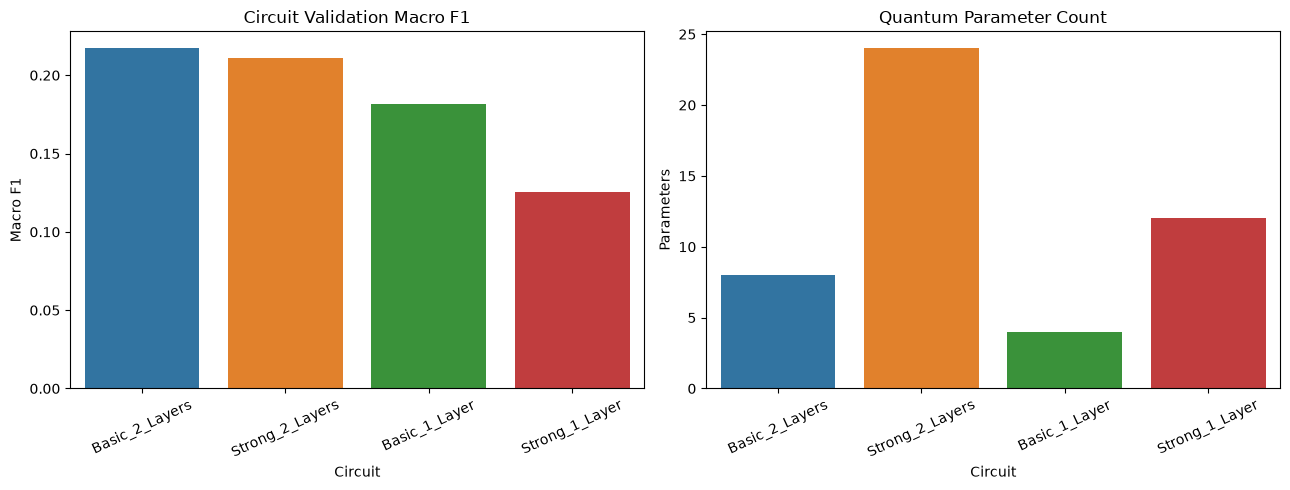

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.barplot(
    data=optimization_results,
    x="circuit_name",
    y="validation_macro_f1",
    hue="circuit_name",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Circuit Validation Macro F1"
)
axes[0].set_xlabel("Circuit")
axes[0].set_ylabel("Macro F1")
axes[0].tick_params(
    axis="x",
    rotation=25
)

sns.barplot(
    data=optimization_results,
    x="circuit_name",
    y="quantum_parameters",
    hue="circuit_name",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Quantum Parameter Count"
)
axes[1].set_xlabel("Circuit")
axes[1].set_ylabel("Parameters")
axes[1].tick_params(
    axis="x",
    rotation=25
)

plt.tight_layout()
plt.show()

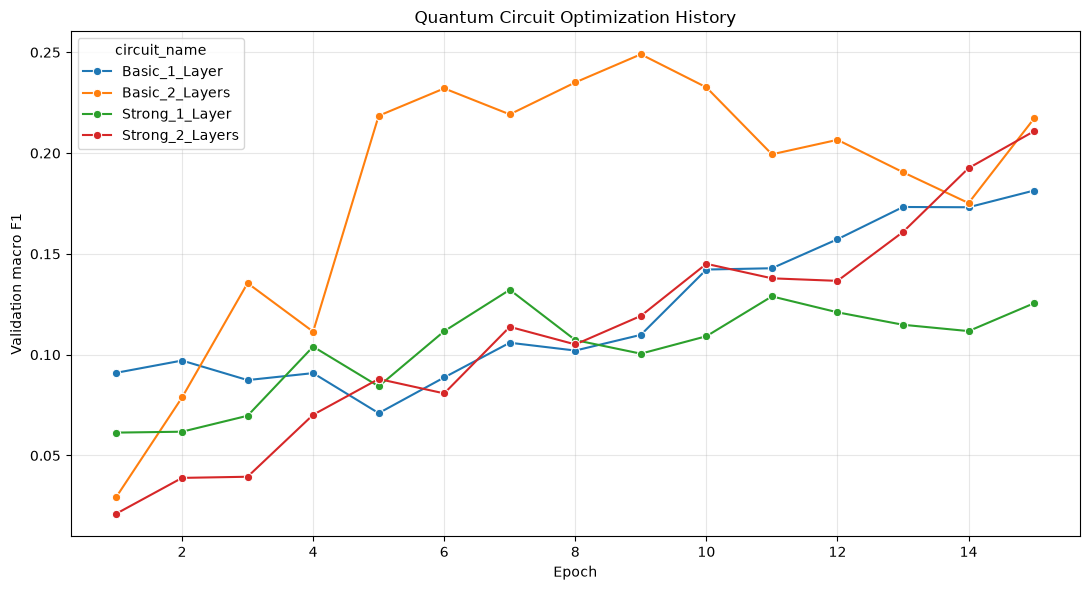

In [15]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=optimization_history,
    x="epoch",
    y="validation_macro_f1",
    hue="circuit_name",
    marker="o"
)

plt.title(
    "Quantum Circuit Optimization History"
)
plt.xlabel("Epoch")
plt.ylabel("Validation macro F1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

optimized_circuit, optimized_weight_shapes = (
    build_quantum_circuit(
        best_template,
        best_layers
    )
)

optimized_model = OptimizedQuantumClassifier(
    quantum_circuit=optimized_circuit,
    weight_shapes=optimized_weight_shapes,
    number_of_classes=n_classes
)

full_training_loader = create_data_loader(
    X_full_train,
    y_full_train,
    batch_size=16,
    shuffle=True
)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    optimized_model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

print(optimized_model)

OptimizedQuantumClassifier(
  (quantum_layer): <Quantum Torch Layer: func=circuit>
  (output_layer): Linear(in_features=4, out_features=12, bias=True)
)


In [17]:
final_training_history = []

for epoch in range(1, best_epoch + 1):
    optimized_model.train()

    total_loss = 0.0
    targets_all = []
    predictions_all = []

    for features, targets in full_training_loader:
        optimizer.zero_grad()

        logits = optimized_model(features)
        loss = loss_function(logits, targets)

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * features.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

        predictions_all.extend(
            predictions.cpu().numpy()
        )

    epoch_loss = (
        total_loss
        / len(full_training_loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        targets_all,
        predictions_all
    )

    final_training_history.append({
        "epoch": epoch,
        "training_loss": epoch_loss,
        "training_accuracy": epoch_accuracy
    })

    print(
        f"Final epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

final_training_history_df = pd.DataFrame(
    final_training_history
)

Final epoch 01 | Loss: 2.5182 | Accuracy: 0.1125
Final epoch 02 | Loss: 2.4339 | Accuracy: 0.1500
Final epoch 03 | Loss: 2.3359 | Accuracy: 0.2175
Final epoch 04 | Loss: 2.1899 | Accuracy: 0.2275
Final epoch 05 | Loss: 2.0320 | Accuracy: 0.2800
Final epoch 06 | Loss: 1.9089 | Accuracy: 0.3100
Final epoch 07 | Loss: 1.8314 | Accuracy: 0.3225
Final epoch 08 | Loss: 1.7801 | Accuracy: 0.3250
Final epoch 09 | Loss: 1.7390 | Accuracy: 0.3400
Final epoch 10 | Loss: 1.7058 | Accuracy: 0.3350
Final epoch 11 | Loss: 1.6801 | Accuracy: 0.3325
Final epoch 12 | Loss: 1.6605 | Accuracy: 0.3350
Final epoch 13 | Loss: 1.6424 | Accuracy: 0.3475
Final epoch 14 | Loss: 1.6262 | Accuracy: 0.3350
Final epoch 15 | Loss: 1.6109 | Accuracy: 0.3475


In [18]:
example_input = torch.tensor(
    X_full_train[0],
    dtype=torch.float32
)

example_weights = torch.zeros(
    optimized_weight_shapes["weights"],
    dtype=torch.float32
)

print(
    qml.draw(optimized_circuit)(
        example_input,
        example_weights
    )
)

0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤  <Z>

M0 = 
tensor([-0.8315, -0.3882, -1.0441,  1.6318])
M1 = 
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [19]:
optimized_model.eval()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

with torch.no_grad():
    test_logits = optimized_model(
        X_test_tensor
    )

    test_probabilities = torch.softmax(
        test_logits,
        dim=1
    ).cpu().numpy()

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

_, _, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

top_3_classes = np.argsort(
    test_probabilities,
    axis=1
)[:, -3:]

top_3_accuracy = np.mean([
    true_class in predicted_classes
    for true_class, predicted_classes
    in zip(y_test, top_3_classes)
])

test_metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "top_3_accuracy"
    ],
    "value": [
        test_accuracy,
        test_balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1,
        top_3_accuracy
    ]
})

display(test_metrics)

,metric,value
0,accuracy,0.340000
1,balanced_accuracy,0.310880
2,macro_precision,0.227721
3,macro_recall,0.310880
4,macro_f1,0.246197
5,weighted_f1,0.266539
6,top_3_accuracy,0.750000


In [20]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=class_ids,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,8.00
1,0.000000,0.000000,0.000000,7.00
2,0.375000,0.666667,0.480000,9.00
3,0.250000,0.125000,0.166667,8.00
4,0.272727,0.900000,0.418605,10.00
5,0.200000,0.125000,0.153846,8.00
6,0.333333,0.333333,0.333333,9.00
7,0.500000,0.555556,0.526316,9.00
8,0.000000,0.000000,0.000000,7.00
9,0.444444,0.400000,0.421053,10.00


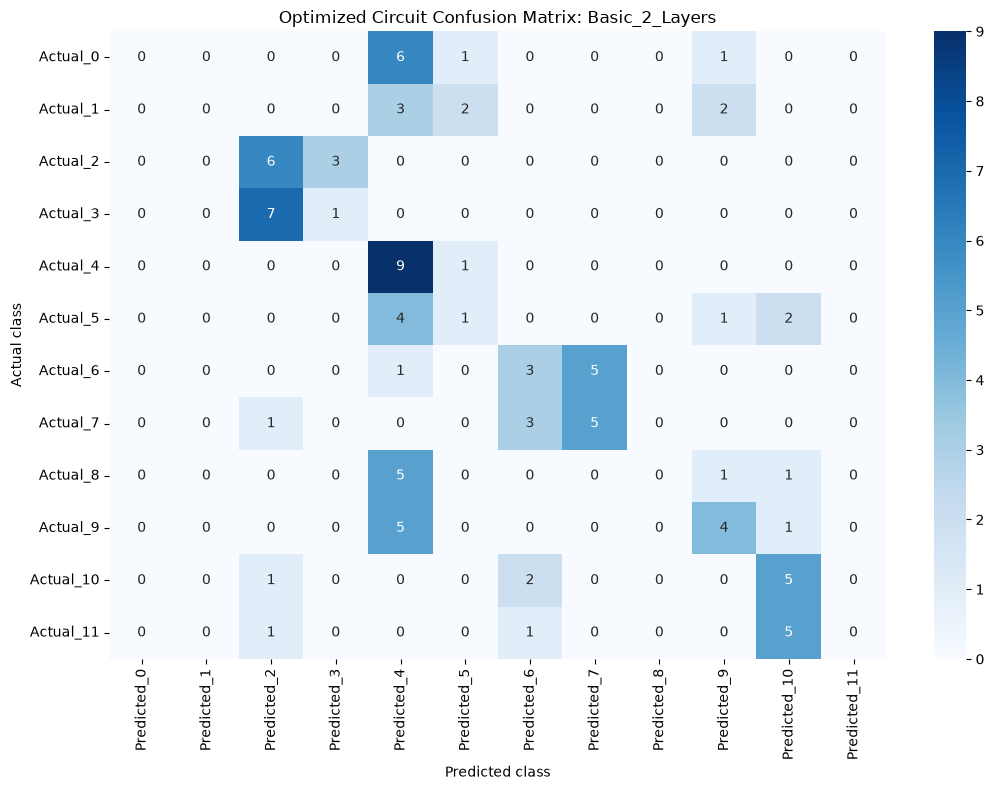

In [21]:
confusion = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_ids
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        f"Actual_{class_id}"
        for class_id in class_ids
    ],
    columns=[
        f"Predicted_{class_id}"
        for class_id in class_ids
    ]
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Optimized Circuit Confusion Matrix: "
    f"{best_circuit_name}"
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

In [22]:
class_mapping.columns = (
    class_mapping.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

encoded_column = (
    "encoded_label"
    if "encoded_label" in class_mapping.columns
    else "encoded_target"
)

medicine_column = (
    "historical_medication_class"
)

if encoded_column not in class_mapping.columns:
    raise KeyError(
        "Encoded class column was not found."
    )

if medicine_column not in class_mapping.columns:
    raise KeyError(
        "Medication-class column was not found."
    )

mapping_dictionary = {
    int(encoded_class): str(medicine_class)
    for encoded_class, medicine_class in zip(
        class_mapping[encoded_column],
        class_mapping[medicine_column]
    )
}

In [23]:
top_3_descending = np.argsort(
    test_probabilities,
    axis=1
)[:, -3:][:, ::-1]

prediction_results = pd.DataFrame({
    "actual_encoded_target": y_test,
    "predicted_encoded_target": test_predictions,
    "actual_medication_class": [
        mapping_dictionary.get(
            int(value),
            f"Class_{value}"
        )
        for value in y_test
    ],
    "predicted_medication_class": [
        mapping_dictionary.get(
            int(value),
            f"Class_{value}"
        )
        for value in test_predictions
    ],
    "prediction_confidence": np.max(
        test_probabilities,
        axis=1
    ),
    "prediction_correct": (
        y_test == test_predictions
    )
})

for rank in range(3):
    rank_ids = top_3_descending[:, rank]

    prediction_results[
        f"rank_{rank + 1}_medication_class"
    ] = [
        mapping_dictionary.get(
            int(class_id),
            f"Class_{class_id}"
        )
        for class_id in rank_ids
    ]

    prediction_results[
        f"rank_{rank + 1}_score"
    ] = [
        test_probabilities[row, class_id]
        for row, class_id in enumerate(rank_ids)
    ]

display(prediction_results.head(10))

,actual_encoded_target,predicted_encoded_target,actual_medication_class,predicted_medication_class,prediction_confidence,prediction_correct,rank_1_medication_class,rank_1_score,rank_2_medication_class,rank_2_score,rank_3_medication_class,rank_3_score
0,9,9,Controller inhaler class,Controller inhaler class,0.169104,True,Controller inhaler class,0.169104,Antihistamine class A,0.163679,Bronchodilator class,0.125592
1,2,2,Antidiabetic class A,Antidiabetic class A,0.452150,True,Antidiabetic class A,0.452150,Antidiabetic class B,0.326860,Lipid-lowering class A,0.116731
2,10,10,Lipid-lowering class A,Lipid-lowering class A,0.363145,True,Lipid-lowering class A,0.363145,Lipid-lowering class B,0.226001,Antidiabetic class A,0.073196
3,10,10,Lipid-lowering class A,Lipid-lowering class A,0.263041,True,Lipid-lowering class A,0.263041,Lipid-lowering class B,0.188574,Antidiabetic class A,0.120563
4,5,4,Antihistamine class B,Antihistamine class A,0.205983,False,Antihistamine class A,0.205983,Controller inhaler class,0.191558,Acid-suppression class A,0.140369
5,8,10,Bronchodilator class,Lipid-lowering class A,0.185900,False,Lipid-lowering class A,0.185900,Lipid-lowering class B,0.140739,Antihistamine class A,0.088356
6,7,7,Antihypertensive class B,Antihypertensive class B,0.166801,True,Antihypertensive class B,0.166801,Antihypertensive class A,0.158926,Antidiabetic class A,0.089722
7,3,3,Antidiabetic class B,Antidiabetic class B,0.491475,True,Antidiabetic class B,0.491475,Antidiabetic class A,0.411619,Lipid-lowering class A,0.037437
8,5,10,Antihistamine class B,Lipid-lowering class A,0.208311,False,Lipid-lowering class A,0.208311,Lipid-lowering class B,0.160415,Controller inhaler class,0.085813
9,6,7,Antihypertensive class A,Antihypertensive class B,0.252762,False,Antihypertensive class B,0.252762,Antihypertensive class A,0.217211,Antihistamine class A,0.105111


In [24]:
model_file = (
    "optimized_variational_quantum_model.pt"
)

torch.save(
    {
        "model_state_dict":
            optimized_model.state_dict(),
        "circuit_name": best_circuit_name,
        "template": best_template,
        "layers": best_layers,
        "training_epochs": best_epoch,
        "n_qubits": n_qubits,
        "n_classes": n_classes,
        "weight_shapes":
            optimized_weight_shapes,
        "class_mapping":
            mapping_dictionary,
        "random_state": RANDOM_STATE
    },
    model_file
)

print("Saved model:", model_file)

Saved model: optimized_variational_quantum_model.pt


In [25]:
results_file = (
    "quantum_circuit_optimization_results.xlsx"
)

configuration_file = (
    "quantum_circuit_optimization_config.json"
)

configuration = {
    "stage": "Quantum Circuit Optimization",
    "selected_circuit": best_circuit_name,
    "selected_template": best_template,
    "selected_layers": best_layers,
    "selected_training_epochs": best_epoch,
    "selection_metric": "validation_macro_f1",
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(macro_f1),
    "test_top_3_accuracy": float(top_3_accuracy),
    "random_state": RANDOM_STATE
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    results_file,
    engine="openpyxl"
) as writer:

    optimization_results.to_excel(
        writer,
        sheet_name="Circuit_Comparison",
        index=False
    )

    optimization_history.to_excel(
        writer,
        sheet_name="Optimization_History",
        index=False
    )

    final_training_history_df.to_excel(
        writer,
        sheet_name="Final_Training_History",
        index=False
    )

    test_metrics.to_excel(
        writer,
        sheet_name="Test_Metrics",
        index=False
    )

    classification_report_df.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Test_Predictions",
        index=False
    )

    class_mapping.to_excel(
        writer,
        sheet_name="Class_Mapping",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved results:", results_file)
print("Saved configuration:", configuration_file)

Saved results: quantum_circuit_optimization_results.xlsx
Saved configuration: quantum_circuit_optimization_config.json


In [26]:
output_files = [
    model_file,
    results_file,
    configuration_file
]

for file_name in output_files:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

print("\nSelected circuit:", best_circuit_name)
print("Selected layers:", best_layers)
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1:", round(macro_f1, 4))
print("Top-3 accuracy:", round(top_3_accuracy, 4))

optimized_variational_quantum_model.pt exists: True
quantum_circuit_optimization_results.xlsx exists: True
quantum_circuit_optimization_config.json exists: True

Selected circuit: Basic_2_Layers
Selected layers: 2
Test accuracy: 0.34
Test macro F1: 0.2462
Top-3 accuracy: 0.75
